In [1]:
import numpy as np
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Average, Input
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load models
model1 = load_model('MODElS/CNNBILSTM.keras')
model2 = load_model('MODElS/CNN.keras')
model3 = load_model('MODElS/CNN_lstm.keras')

In [3]:
# Load test datasets
X_test = np.load('TEST1/X_test.npy')
y_test = np.load('TEST1/y_test.npy')

271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Model1 Accuracy: 0.9778162911611785
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6759
           1       0.99      0.99      0.99       667
           2       0.99      0.98      0.98       617
           3       0.97      0.81      0.88       199
           4       0.81      0.91      0.85       413

    accuracy                           0.98      8655
   macro avg       0.95      0.93      0.94      8655
weighted avg       0.98      0.98      0.98      8655

Model1 ROC AUC Score: 0.9970150740523953


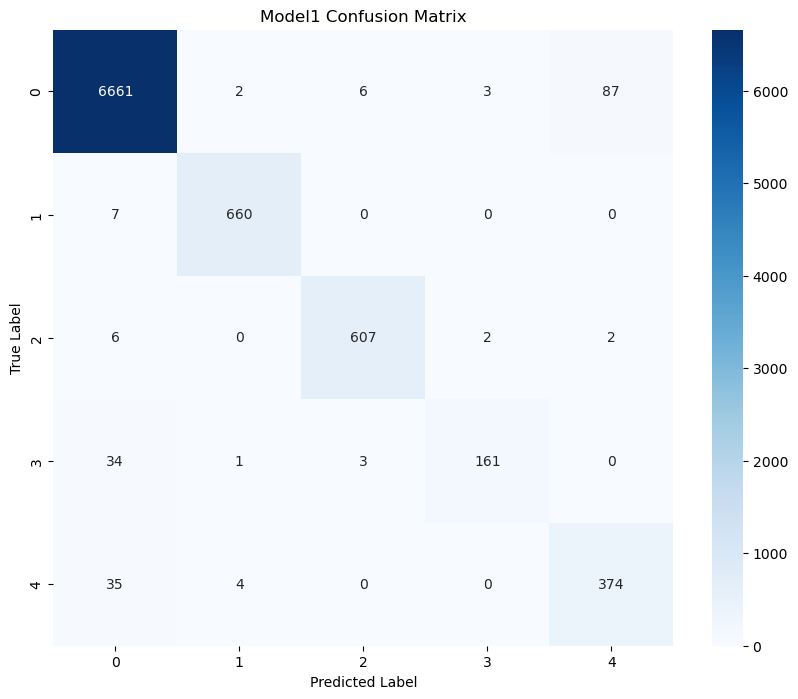

Model1 True Correct Predictions: 8463
Model1 False Predictions: 192
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model2 Accuracy: 0.9564413633737724
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      6759
           1       0.97      0.99      0.98       667
           2       0.97      0.96      0.96       617
           3       0.89      0.72      0.80       199
           4       0.67      0.69      0.68       413

    accuracy                           0.96      8655
   macro avg       0.89      0.87      0.88      8655
weighted avg       0.96      0.96      0.96      8655

Model2 ROC AUC Score: 0.9814998536898821


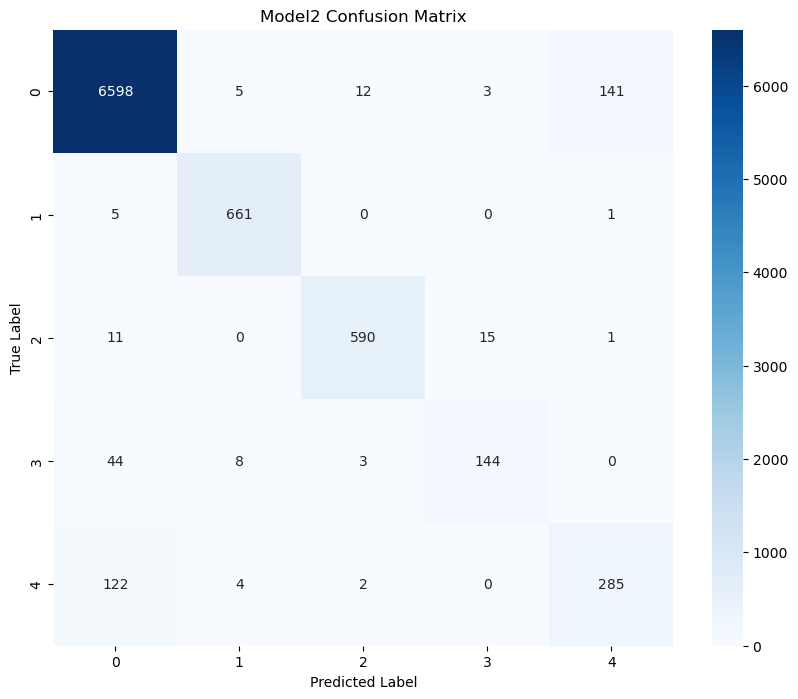

Model2 True Correct Predictions: 8278
Model2 False Predictions: 377
271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Model3 Accuracy: 0.9800115540150203
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      6759
           1       0.99      0.99      0.99       667
           2       0.99      0.97      0.98       617
           3       0.97      0.85      0.90       199
           4       0.88      0.83      0.86       413

    accuracy                           0.98      8655
   macro avg       0.96      0.93      0.94      8655
weighted avg       0.98      0.98      0.98      8655

Model3 ROC AUC Score: 0.994236261213663


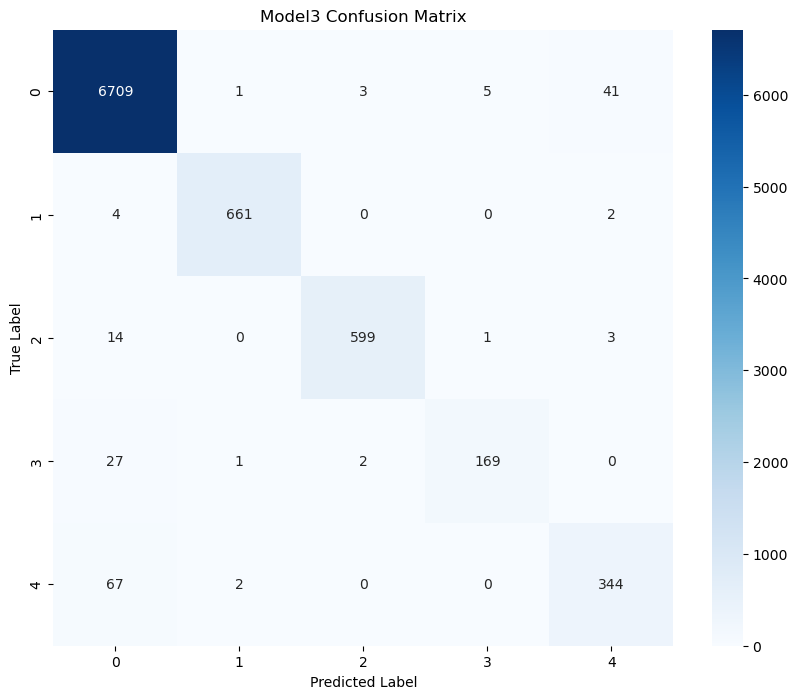

Model3 True Correct Predictions: 8482
Model3 False Predictions: 173


In [4]:
#Define a function to evaluate and plot results for a single model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')

    print(f"{model_name} Accuracy: {accuracy}")
    print("Classification Report:")
    print(class_report)
    print(f"{model_name} ROC AUC Score: {roc_auc}")

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    true_correct = np.sum(y_test == y_pred)
    false_predictions = np.sum(y_test != y_pred)

    print(f"{model_name} True Correct Predictions: {true_correct}")
    print(f"{model_name} False Predictions: {false_predictions}")

# Evaluate each model individually
evaluate_model(model1, X_test, y_test, "Model1")
evaluate_model(model2, X_test, y_test, "Model2")
evaluate_model(model3, X_test, y_test, "Model3")

In [5]:
# Define a function to extract features from each model
def get_model_predictions(model, X):
    return model.predict(X)

In [6]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Prepare the data for stacking
X_train_meta = np.concatenate([get_model_predictions(model1, X_test),
                               get_model_predictions(model2, X_test),
                               get_model_predictions(model3, X_test)], axis=1)

# Create the base estimators
estimators = [
    ('model1', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model2', make_pipeline(StandardScaler(), LogisticRegression())),
    ('model3', make_pipeline(StandardScaler(), LogisticRegression()))
]

# Create the stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

# Train the stacking classifier
stacking_clf.fit(X_train_meta, y_test)

271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


StackingClassifier(estimators=[('model1',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('model2',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())])),
                               ('model3',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression())]))],
                   final_estimator=LogisticRegression())

In [7]:
# Make predictions with the stacking classifier
y_pred_stacking = stacking_clf.predict(X_train_meta)

# Evaluate the ensemble model
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
conf_matrix_stacking = confusion_matrix(y_test, y_pred_stacking)
class_report_stacking = classification_report(y_test, y_pred_stacking)
roc_auc_stacking = roc_auc_score(y_test, stacking_clf.predict_proba(X_train_meta), multi_class='ovr')

print(f"Stacking Ensemble Accuracy: {accuracy_stacking}")
print("Stacking Ensemble Classification Report:")
print(class_report_stacking)
print(f"Stacking Ensemble ROC AUC Score: {roc_auc_stacking}")

Stacking Ensemble Accuracy: 0.9823223570190641
Stacking Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6759
           1       0.99      0.99      0.99       667
           2       0.99      0.99      0.99       617
           3       0.97      0.86      0.91       199
           4       0.90      0.84      0.87       413

    accuracy                           0.98      8655
   macro avg       0.97      0.93      0.95      8655
weighted avg       0.98      0.98      0.98      8655

Stacking Ensemble ROC AUC Score: 0.9938945529886194


In [8]:
# Calculate the true and false predictions
true_correct_stacking = np.sum(y_test == y_pred_stacking)
false_predictions_stacking = np.sum(y_test != y_pred_stacking)

print(f"Stacking Ensemble True Correct Predictions: {true_correct_stacking}")
print(f"Stacking Ensemble False Predictions: {false_predictions_stacking}")

Stacking Ensemble True Correct Predictions: 8502
Stacking Ensemble False Predictions: 153


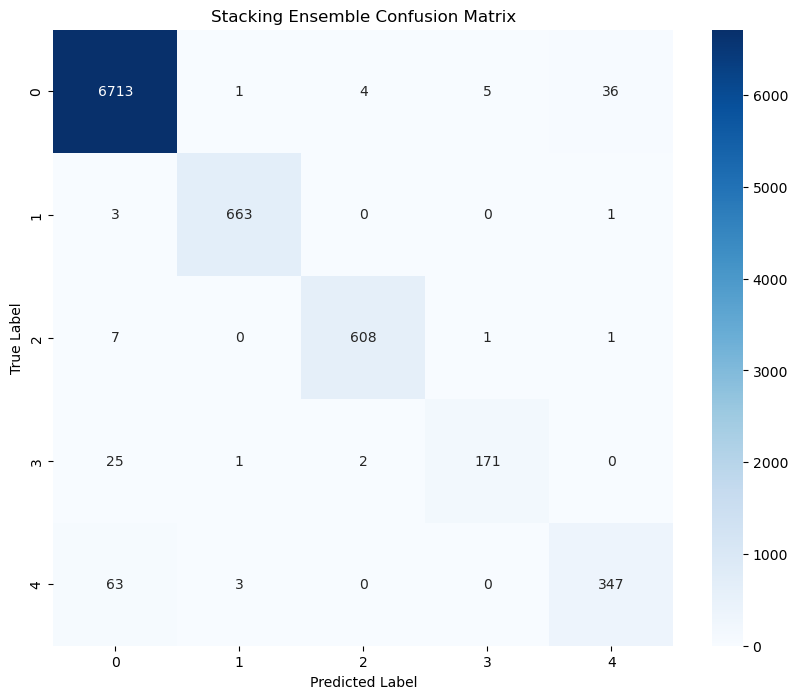

In [9]:
# Plot confusion matrix for stacking ensemble
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_stacking, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Stacking Ensemble Confusion Matrix')
plt.show()

In [10]:
# Compare all models performance 
model_names = ["Model1", "Model2", "Model3", "Stacking Ensemble"]
accuracies = [accuracy_score(y_test, np.argmax(get_model_predictions(model1, X_test), axis=1)),
              accuracy_score(y_test, np.argmax(get_model_predictions(model2, X_test), axis=1)),
              accuracy_score(y_test, np.argmax(get_model_predictions(model3, X_test), axis=1)),
              accuracy_stacking]


271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


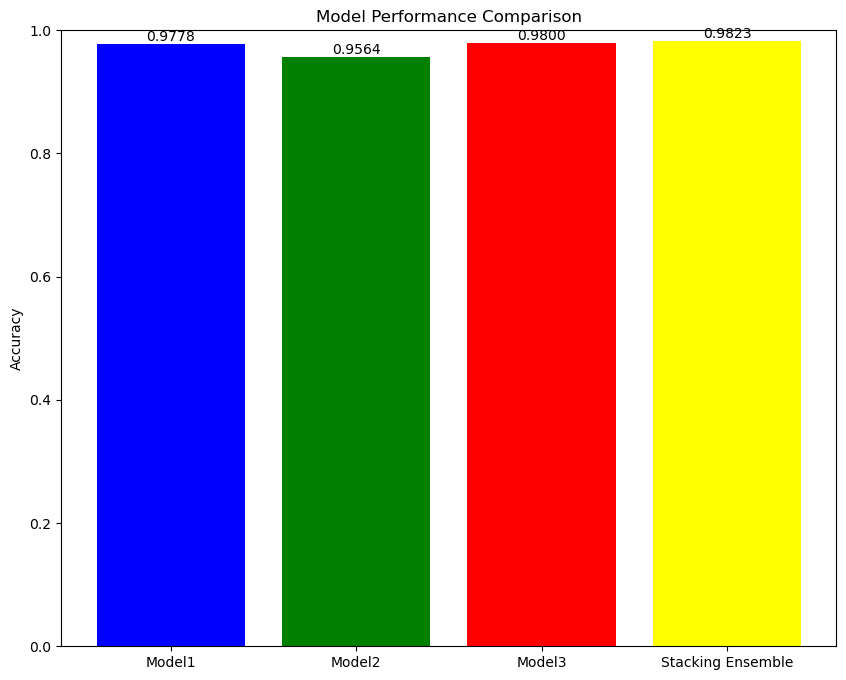

In [11]:
# Define colors for each model
colors = ['blue', 'green', 'red', 'yellow']

plt.figure(figsize=(10, 8))
plt.bar(model_names, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
for index, value in enumerate(accuracies):
    plt.text(index, value, f'{value:.4f}', ha='center', va='bottom')
plt.show()

In [12]:
import joblib

# Save the stacking classifier model
stacking_model_path = 'MODElS/ensemble.pkl'
joblib.dump(stacking_clf, stacking_model_path)


['MODElS/ensemble.pkl']

In [13]:
# Save the X_train_meta array
np.save('TEST1/X_train_meta.npy', X_train_meta)